# Continuous Batching Benchmark

Compares naive (static) batching against continuous (iteration-level)
batching across 10, 50, and 100 concurrent users. Numbers come from
`02_batching_sim/results.csv`, produced by `02_batching_sim/benchmark.py`.

Workload: Poisson arrivals at 5 req/s, log-normal prompt (median 50) and
output (median 80) lengths, max_batch_size = 8.

Reproduce the numbers:
    uv run 02_batching_sim/benchmark.py

In [1]:
import pandas as pd

df = pd.read_csv("../02_batching_sim/results.csv")
df[["users", "policy", "throughput_rps", "ttft_p50_ms",
    "itl_p95_ms", "latency_p95_ms"]]

,users,policy,throughput_rps,ttft_p50_ms,itl_p95_ms,latency_p95_ms
0,10,naive_batching,2.316405,1369.691632,15.595929,2630.761613
1,10,continuous_batching,3.792631,12.810825,9.354821,963.937873
2,50,naive_batching,2.089429,6003.756432,14.468300,14614.778453
3,50,continuous_batching,4.523396,17.545646,12.997685,2983.135417
4,100,naive_batching,2.063309,12444.570388,15.171813,29644.264671
5,100,continuous_batching,4.432126,17.617971,13.047919,3224.852569


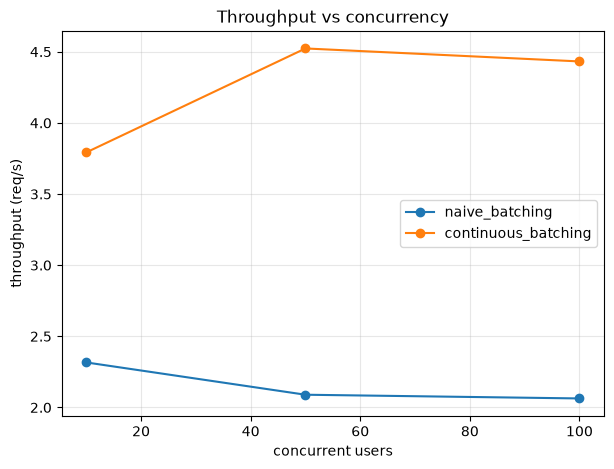

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for policy in ("naive_batching", "continuous_batching"):
    sub = df[df["policy"] == policy]
    ax.plot(sub["users"], sub["throughput_rps"], "o-", label=policy)
ax.set_xlabel("concurrent users")
ax.set_ylabel("throughput (req/s)")
ax.set_title("Throughput vs concurrency")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()fig, ax = plt.subplots(figsize=(7, 5))
for policy in ("naive_batching", "continuous_batching"):
    sub = df[df["policy"] == policy]
    ax.plot(sub["users"], sub["latency_p95_ms"], "o-", label=policy)
ax.set_xlabel("concurrent users")
ax.set_ylabel("P95 end-to-end latency (ms)")
ax.set_title("P95 latency vs concurrency")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

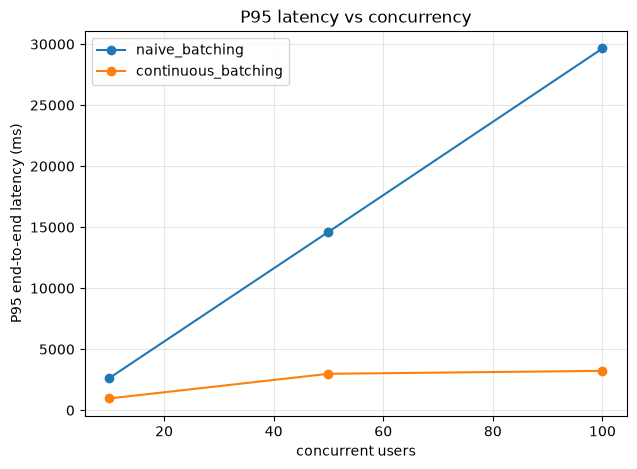

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for policy in ("naive_batching", "continuous_batching"):
    sub = df[df["policy"] == policy]
    ax.plot(sub["users"], sub["latency_p95_ms"], "o-", label=policy)
ax.set_xlabel("concurrent users")
ax.set_ylabel("P95 end-to-end latency (ms)")
ax.set_title("P95 latency vs concurrency")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## What this shows

**Naive throughput degrades with load; continuous stays flat.**
Naive batches wait for their slowest member. As concurrency rises, the
number of batches rises, and each is a fresh draw from a heavy-tailed
output-length distribution — more chances to stall. Continuous decouples
slots: a long request occupies one, others keep turning over.

**Tail latency diverges by ~9× at 100 users.** Naive queues requests
behind full batches; continuous admits each request as soon as a slot
opens.

**Continuous also wins at low concurrency.** At 10 users, naive TTFT P50
is 1.4 s because the batcher waits for a full batch to assemble.
Continuous starts on arrival. So the win isn't only under load.

**The tradeoff.** Continuous batching slightly raises ITL for
co-scheduled requests when a prefill interferes with the current decode
step. Production systems mitigate this with chunked prefill. Here the
effect is minor because prefills are cheap; with long prompts it would
dominate.

Full writeup: `README.md` § "Continuous batching".